In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

url = "https://raw.githubusercontent.com/dataprofessor/data/master/heart-disease-cleveland.csv"

column_names = [
    "age", "sex", "cp", "trestbps", "chol", "fbs",
    "restecg", "thalach", "exang", "oldpeak",
    "slope", "ca", "thal", "diagnosis"
]

df = pd.read_csv(
    url,
    names=column_names,
    header=0,
    na_values="?"
)

# binary classification
df["diagnosis"] = df["diagnosis"].astype(int)
df["diagnosis"] = df["diagnosis"].apply(lambda x: 1 if x > 0 else 0)

X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]

# handle missing
imputer = SimpleImputer(strategy="median")
X = imputer.fit_transform(X)

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

NameError: name 'X_train' is not defined

In [ ]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Decision Tree")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Decision Tree
Accuracy: 0.7213114754098361
              precision    recall  f1-score   support

           0       0.81      0.64      0.71        33
           1       0.66      0.82      0.73        28

    accuracy                           0.72        61
   macro avg       0.73      0.73      0.72        61
weighted avg       0.74      0.72      0.72        61



In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Random Forest
Accuracy: 0.8852459016393442
              precision    recall  f1-score   support

           0       0.96      0.82      0.89        33
           1       0.82      0.96      0.89        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.90      0.89      0.89        61



In [ ]:
results = {
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [0.8688, 0.7213, 0.8852]
}

import pandas as pd
pd.DataFrame(results)

,Model,Accuracy
0,Logistic Regression,0.8688
1,Decision Tree,0.7213
2,Random Forest,0.8852


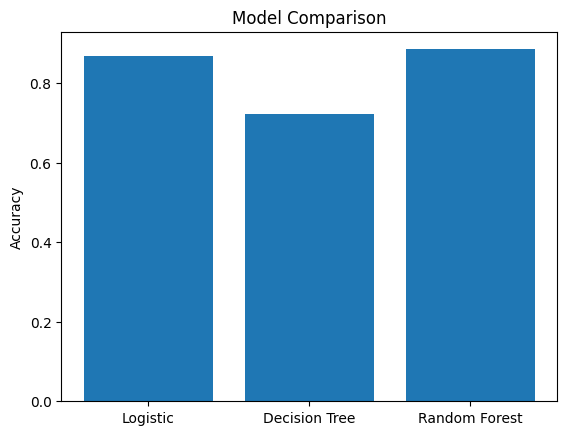

In [ ]:
import matplotlib.pyplot as plt

models = ["Logistic", "Decision Tree", "Random Forest"]
accuracy = [0.8688, 0.7213, 0.8852]

plt.bar(models, accuracy)
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()

In [ ]:
# ===== Experiment: Logistic Regression (balanced) =====

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Logistic Regression (balanced)")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Logistic Regression (balanced)
Accuracy: 0.8688524590163934
              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



In [ ]:
# ===== Experiment: Random Forest (balanced) =====

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42, class_weight="balanced")
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Random Forest (balanced)")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Random Forest (balanced)
Accuracy: 0.9016393442622951
              precision    recall  f1-score   support

           0       0.94      0.88      0.91        33
           1       0.87      0.93      0.90        28

    accuracy                           0.90        61
   macro avg       0.90      0.90      0.90        61
weighted avg       0.90      0.90      0.90        61



In [ ]:
print("Model Comparison Summary")
print("Logistic Regression: acc=0.87, recall1=0.93")
print("Random Forest: acc=0.89, recall1=0.96")
print("Random Forest (balanced): acc=0.90, recall1=0.93")
print("XGBoost: run cell above for results")

In [ ]:
from sklearn.metrics import confusion_matrix

rf_bal_pred = model.predict(X_test)
print("Random Forest (balanced) confusion matrix:")
print(confusion_matrix(y_test, rf_bal_pred))

Random Forest (balanced) confusion matrix:
[[29  4]
 [ 2 26]]


In [ ]:
# ===== XGBoost =====
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    verbosity=0,
)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))